# Thermal Hotspot vs Tree Canopy Overlay

**Authored by:** Thien Khang Nguyen  
**Level:** Intermediate  
**Focus:** Geospatial overlay of thermal intensity and tree canopy cover in Melbourne

This notebook rebuilds the original workflow for identifying places where **surface temperature is relatively high** and **tree canopy cover is relatively low**. It uses the 2021 tree canopy polygons already available in this folder and is ready to integrate the 2012 thermal raster once that file is added.


## Project context

Urban heat is a key liveability issue in Melbourne. Built surfaces such as roads, roofs, and pavements can retain heat, while tree canopy often helps moderate local temperature through shade and evapotranspiration.

The aim of this analysis is to combine:

- **Thermal Image 2012** to represent surface heat patterns.
- **Tree Canopies 2021 (Urban Forest)** to represent vegetation cover.

The results should be interpreted as **exploratory spatial analysis**, not a same-year causal comparison, because the datasets come from different years.

## Expected files

- `tree-canopies-2021-urban-forest.geojson`
- A thermal raster such as `thermal-image-2012.tif` or any `*.tif` / `*.tiff` placed in the same folder

If the thermal raster is missing, the notebook will still run the canopy inspection steps and will clearly tell you where to add the raster.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

try:
    import rasterio
    from rasterio.mask import mask
    from rasterio.plot import show
except ImportError:
    rasterio = None
    mask = None
    show = None

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

search_roots = [
    Path.cwd(),
    Path.cwd() / "Playground" / "ThienKhangNGUYEN",
    Path("Playground/ThienKhangNGUYEN"),
]

NOTEBOOK_DIR = next(
    (path for path in search_roots if (path / "tree-canopies-2021-urban-forest.geojson").exists()),
    Path.cwd(),
)

CANOPY_PATH = NOTEBOOK_DIR / "tree-canopies-2021-urban-forest.geojson"
_thermal_candidates = [
    *NOTEBOOK_DIR.rglob("*thermal*.tif"),
    *NOTEBOOK_DIR.rglob("*thermal*.tiff"),
    *NOTEBOOK_DIR.rglob("*.tif"),
    *NOTEBOOK_DIR.rglob("*.tiff"),
]
THERMAL_CANDIDATES = sorted(set(_thermal_candidates), key=lambda p: str(p).lower())
THERMAL_RASTER_PATH = THERMAL_CANDIDATES[0] if THERMAL_CANDIDATES else None
GRID_SIZE_METERS = 500

print(f"Working directory: {NOTEBOOK_DIR.resolve()}")
print(f"Canopy file found: {CANOPY_PATH.exists()} -> {CANOPY_PATH.name}")
print(f"Thermal raster found: {THERMAL_RASTER_PATH if THERMAL_RASTER_PATH else 'Not found'}")

if rasterio is None:
    print("rasterio is not installed. Run `pip install rasterio` before executing the thermal-analysis cells.")


Working directory: D:\DEAKIN\SIT374\project\MOP-Code\Playground\ThienKhangNGUYEN
Canopy file found: True -> tree-canopies-2021-urban-forest.geojson
Thermal raster found: D:\DEAKIN\SIT374\project\MOP-Code\Playground\ThienKhangNGUYEN\GeoTiff_1\Thermal.tif


## 1. Load and inspect the tree canopy dataset

The canopy data is stored as a GeoJSON polygon layer. GeoJSON normally uses longitude/latitude coordinates in `EPSG:4326`, so if the CRS is missing we explicitly assign that CRS before reprojecting for area calculations.


Rows: 57,980
Source CRS: EPSG:4326
Total canopy area (sq km): 4.42


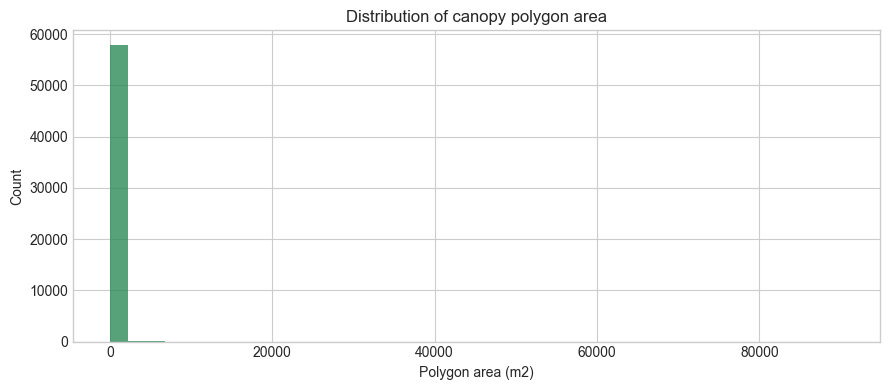

In [2]:
canopy_gdf = gpd.read_file(CANOPY_PATH)

if canopy_gdf.crs is None:
    canopy_gdf = canopy_gdf.set_crs(epsg=4326)

canopy_gdf = canopy_gdf[canopy_gdf.geometry.notna()].copy()
canopy_gdf = canopy_gdf.explode(index_parts=False).reset_index(drop=True)

canopy_projected = canopy_gdf.to_crs(epsg=32755)
canopy_projected["canopy_area_m2"] = canopy_projected.geometry.area

print(f"Rows: {len(canopy_gdf):,}")
print(f"Source CRS: {canopy_gdf.crs}")
print(f"Total canopy area (sq km): {canopy_projected['canopy_area_m2'].sum() / 1_000_000:,.2f}")

canopy_projected[["canopy_area_m2"]].describe()


fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(canopy_projected["canopy_area_m2"], bins=40, color="seagreen", alpha=0.8)
ax.set_title("Distribution of canopy polygon area")
ax.set_xlabel("Polygon area (m2)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


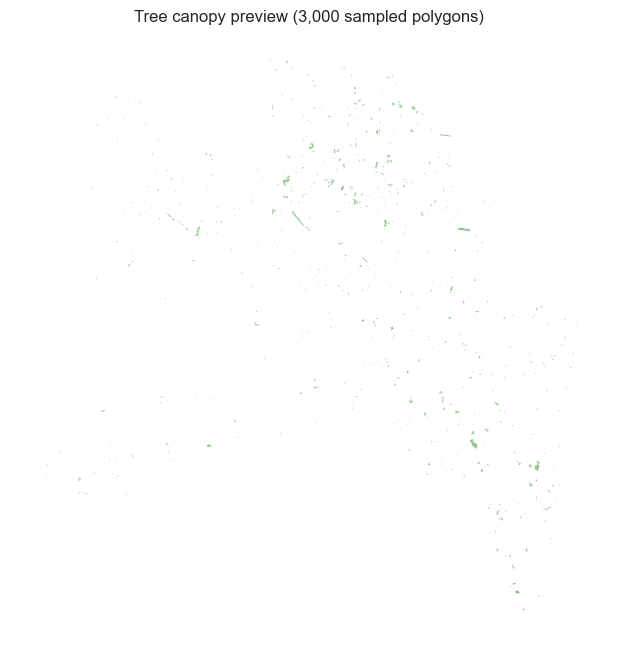

In [3]:
sample_size = min(3000, len(canopy_gdf))
canopy_preview = canopy_gdf.sample(sample_size, random_state=42) if len(canopy_gdf) > sample_size else canopy_gdf

fig, ax = plt.subplots(figsize=(8, 8))
canopy_preview.plot(ax=ax, color="forestgreen", alpha=0.55, linewidth=0)
ax.set_title(f"Tree canopy preview ({sample_size:,} sampled polygons)")
ax.set_axis_off()
plt.show()


## 2. Thermal raster setup

Place the thermal raster in the same folder as this notebook. If the auto-detected file is wrong, manually overwrite `THERMAL_RASTER_PATH` in the next cell.

The grid-based overlay analysis assumes the raster uses a **projected CRS** so that cell size and canopy area are meaningful in metres.


Thermal raster: Thermal.tif
CRS: EPSG:28355
Bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)
Resolution: (3.3864573980742643, 3.386031538303843)


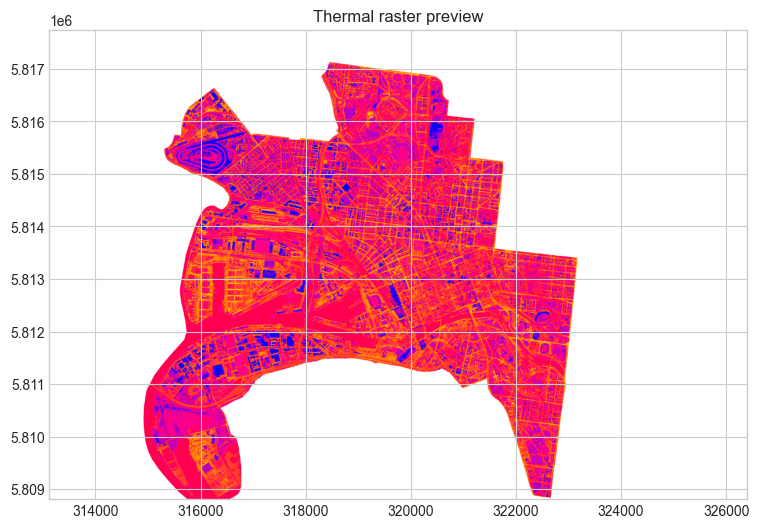

In [4]:
def make_grid(bounds, cell_size):
    xmin, ymin, xmax, ymax = bounds
    cols = np.arange(xmin, xmax, cell_size)
    rows = np.arange(ymin, ymax, cell_size)

    cells = []
    grid_id = 0
    for x in cols:
        for y in rows:
            cells.append({"grid_id": grid_id, "geometry": box(x, y, x + cell_size, y + cell_size)})
            grid_id += 1

    return gpd.GeoDataFrame(cells, crs=None)


def masked_mean_from_polygon(src, geom):
    clipped, _ = mask(src, [geom], crop=True, filled=False)
    data = clipped[0]
    if hasattr(data, "compressed"):
        values = data.compressed()
    else:
        values = data[~np.isnan(data)]
    return float(values.mean()) if values.size else np.nan


thermal_ready = THERMAL_RASTER_PATH is not None and rasterio is not None

if not thermal_ready:
    print("Thermal raster not found yet.")
    print("Add the 2012 thermal raster into the same folder as this notebook, then rerun this cell.")
    print("Accepted names include anything matching *.tif, *.tiff, or *thermal*.")
else:
    with rasterio.open(THERMAL_RASTER_PATH) as src:
        print(f"Thermal raster: {THERMAL_RASTER_PATH.name}")
        print(f"CRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        print(f"Resolution: {src.res}")
        if not src.crs or not src.crs.is_projected:
            print("Warning: the raster CRS is not projected. Reproject it before relying on area-based hotspot metrics.")

        fig, ax = plt.subplots(figsize=(9, 7))
        show(src, ax=ax, cmap="inferno")
        ax.set_title("Thermal raster preview")
        plt.show()


## 3. Overlay canopy and temperature on a shared grid

This step creates regular grid cells, calculates:

- mean thermal value per cell
- canopy cover percentage per cell
- a combined hotspot score

Cells are flagged as hotspots when they are in the **upper quartile of temperature** and the **lower quartile of canopy cover**.


Grid cells analysed: 486
Hotspot cells: 287
Temperature threshold (Q3): 255.00
Canopy threshold (Q1): 0.00%


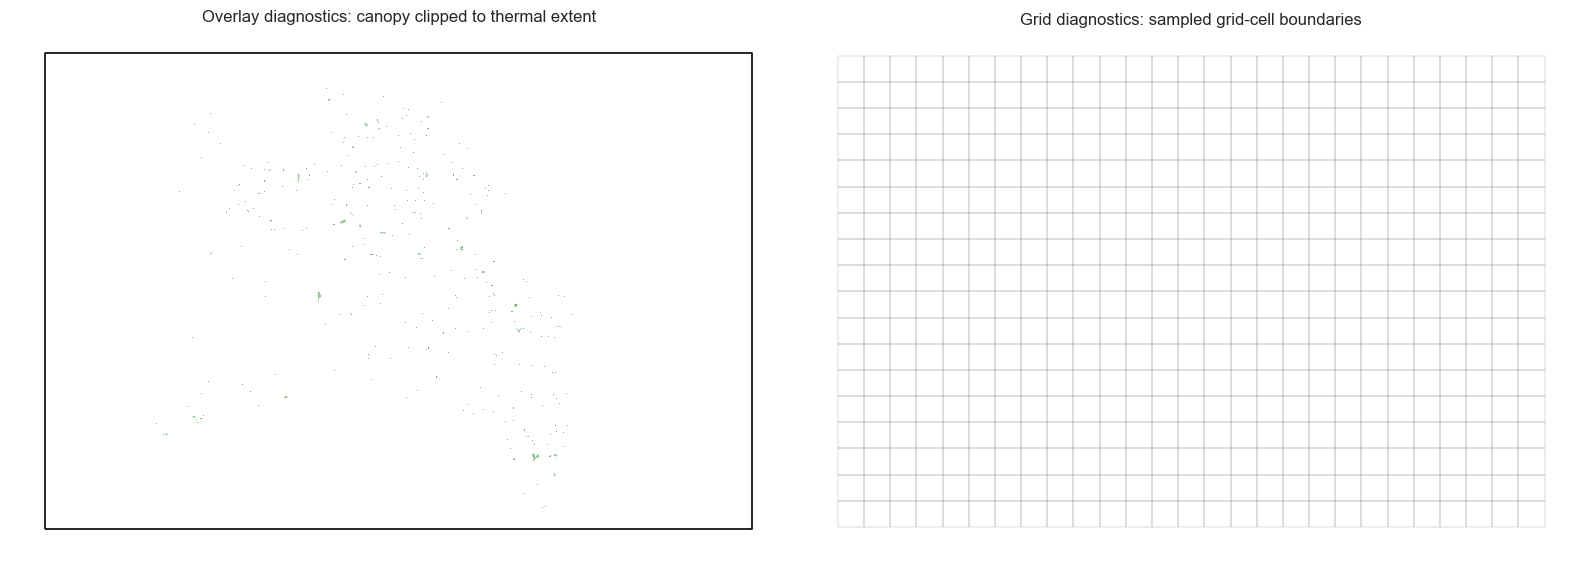

In [5]:
if thermal_ready:
    with rasterio.open(THERMAL_RASTER_PATH) as src:
        if not src.crs or not src.crs.is_projected:
            raise ValueError("Thermal raster must use a projected CRS, for example EPSG:32755, before running the overlay analysis.")

        canopy_in_raster_crs = canopy_gdf.to_crs(src.crs)
        raster_extent = gpd.GeoDataFrame(geometry=[box(*src.bounds)], crs=src.crs)
        canopy_clip = gpd.clip(canopy_in_raster_crs, raster_extent)

        grid = make_grid(src.bounds, GRID_SIZE_METERS).set_crs(src.crs)
        grid["cell_area_m2"] = grid.geometry.area

        if len(canopy_clip):
            canopy_overlay = gpd.overlay(
                grid[["grid_id", "geometry"]],
                canopy_clip[["geometry"]],
                how="intersection",
            )
            canopy_overlay["canopy_overlap_m2"] = canopy_overlay.geometry.area
            canopy_by_cell = canopy_overlay.groupby("grid_id")["canopy_overlap_m2"].sum()
        else:
            canopy_by_cell = pd.Series(dtype="float64")

        grid["canopy_cover_pct"] = grid["grid_id"].map(canopy_by_cell).fillna(0) / grid["cell_area_m2"] * 100
        grid["mean_surface_temp"] = [masked_mean_from_polygon(src, geom) for geom in grid.geometry]
        grid = grid.dropna(subset=["mean_surface_temp"]).copy()

        temp_min = grid["mean_surface_temp"].min()
        temp_span = grid["mean_surface_temp"].max() - temp_min
        canopy_max = grid["canopy_cover_pct"].max()

        grid["temp_norm"] = (grid["mean_surface_temp"] - temp_min) / temp_span if temp_span else 0
        grid["canopy_inverse_norm"] = 1 - (grid["canopy_cover_pct"] / canopy_max) if canopy_max else 1
        grid["hotspot_score"] = 0.65 * grid["temp_norm"] + 0.35 * grid["canopy_inverse_norm"]

        temp_q75 = grid["mean_surface_temp"].quantile(0.75)
        canopy_q25 = grid["canopy_cover_pct"].quantile(0.25)
        grid["is_hotspot"] = (grid["mean_surface_temp"] >= temp_q75) & (grid["canopy_cover_pct"] <= canopy_q25)

        print(f"Grid cells analysed: {len(grid):,}")
        print(f"Hotspot cells: {int(grid['is_hotspot'].sum()):,}")
        print(f"Temperature threshold (Q3): {temp_q75:.2f}")
        print(f"Canopy threshold (Q1): {canopy_q25:.2f}%")

        clip_preview = canopy_clip.sample(min(2500, len(canopy_clip)), random_state=42) if len(canopy_clip) else canopy_clip
        grid_preview = grid.sample(min(5000, len(grid)), random_state=42)

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        raster_extent.boundary.plot(ax=axes[0], color="black", linewidth=1.2)
        if len(clip_preview):
            clip_preview.plot(ax=axes[0], color="forestgreen", alpha=0.6, linewidth=0)
        axes[0].set_title("Overlay diagnostics: canopy clipped to thermal extent")
        axes[0].set_axis_off()

        grid_preview.boundary.plot(ax=axes[1], color="gray", linewidth=0.2)
        axes[1].set_title("Grid diagnostics: sampled grid-cell boundaries")
        axes[1].set_axis_off()
        plt.tight_layout()
        plt.show()
else:
    print("Skipping overlay analysis until a thermal raster is available.")


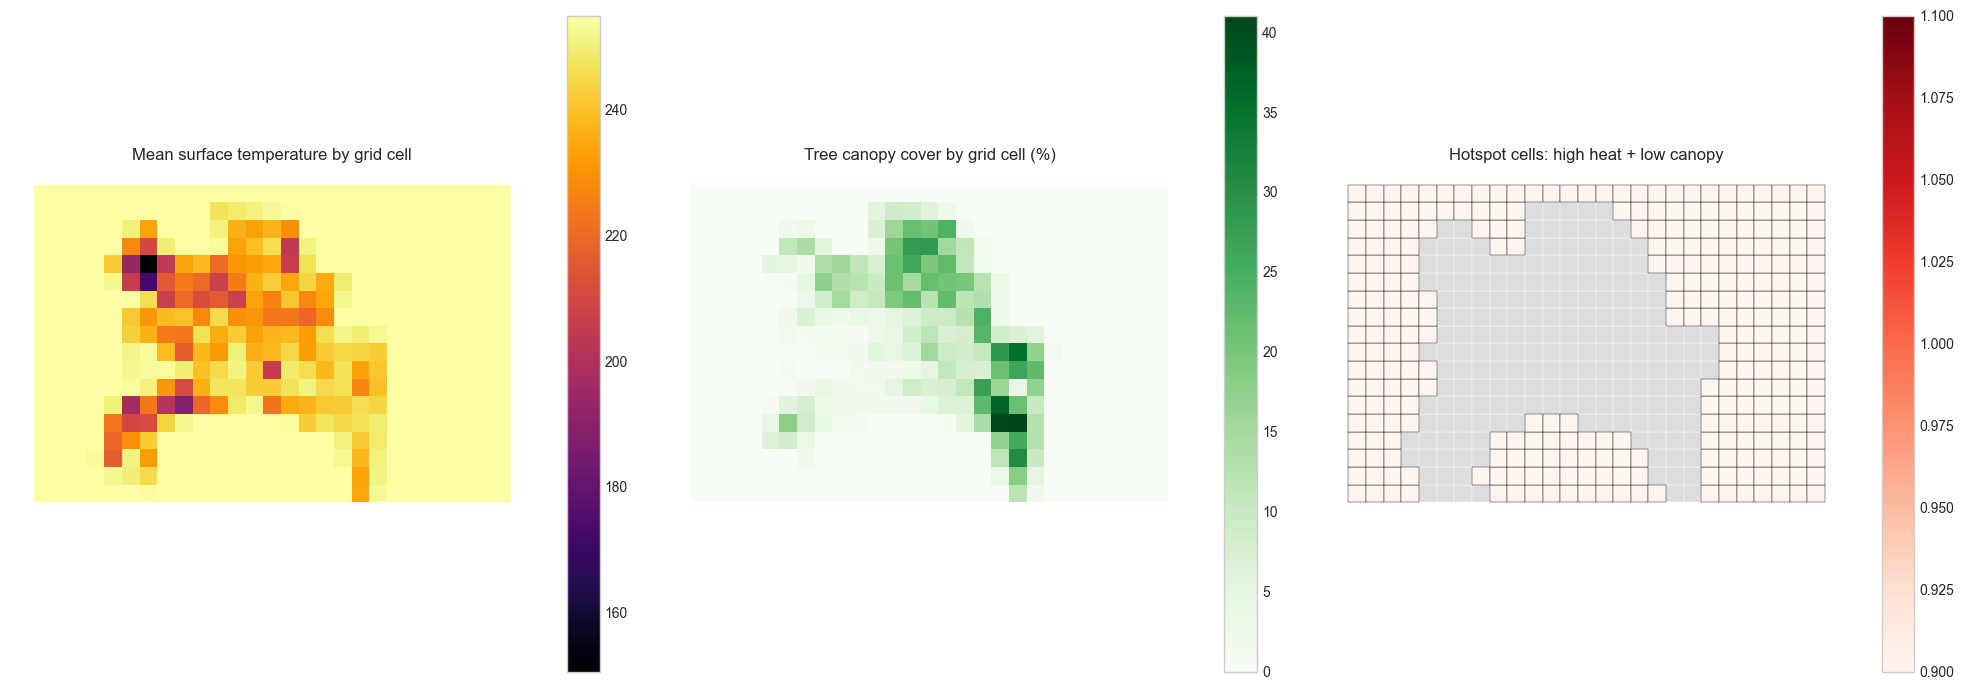

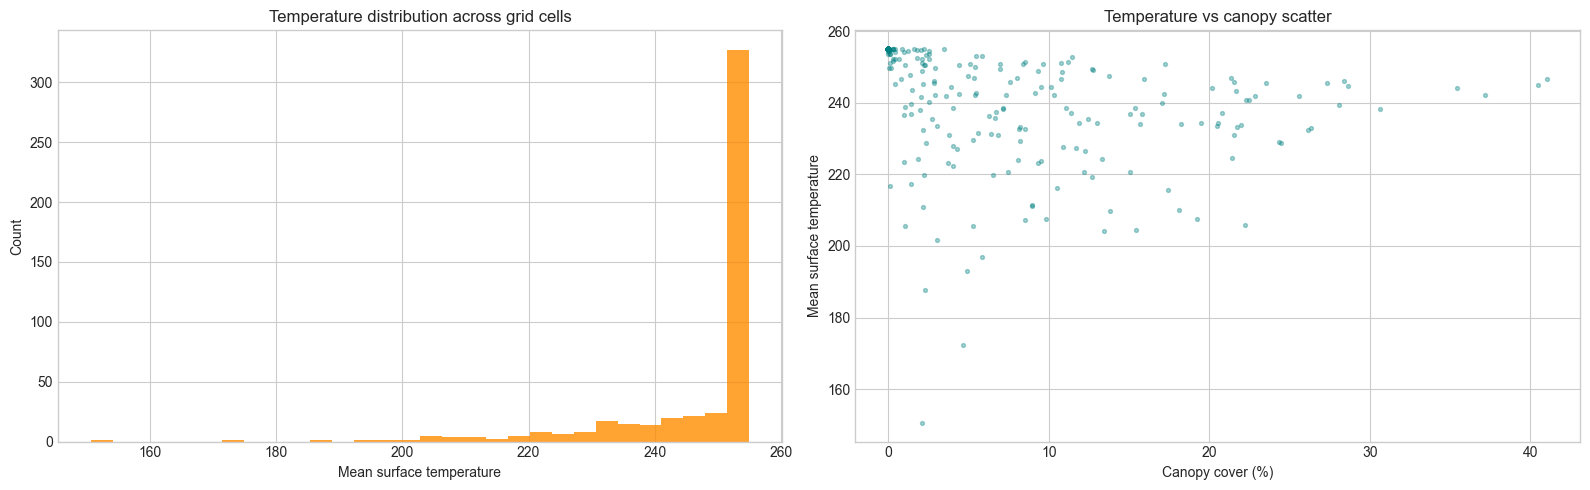

In [6]:
if thermal_ready and not grid.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    grid.plot(column="mean_surface_temp", ax=axes[0], cmap="inferno", legend=True)
    axes[0].set_title("Mean surface temperature by grid cell")
    axes[0].set_axis_off()

    grid.plot(column="canopy_cover_pct", ax=axes[1], cmap="Greens", legend=True)
    axes[1].set_title("Tree canopy cover by grid cell (%)")
    axes[1].set_axis_off()

    grid.plot(ax=axes[2], color="#dddddd", edgecolor="white", linewidth=0.3)
    grid[grid["is_hotspot"]].plot(
        column="hotspot_score",
        ax=axes[2],
        cmap="Reds",
        legend=True,
        edgecolor="black",
        linewidth=0.3,
    )
    axes[2].set_title("Hotspot cells: high heat + low canopy")
    axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(grid["mean_surface_temp"], bins=30, color="darkorange", alpha=0.8)
    axes[0].set_title("Temperature distribution across grid cells")
    axes[0].set_xlabel("Mean surface temperature")
    axes[0].set_ylabel("Count")

    axes[1].scatter(grid["canopy_cover_pct"], grid["mean_surface_temp"], s=8, alpha=0.35, color="teal")
    axes[1].set_title("Temperature vs canopy scatter")
    axes[1].set_xlabel("Canopy cover (%)")
    axes[1].set_ylabel("Mean surface temperature")
    plt.tight_layout()
    plt.show()

    hotspot_table = (
        grid.loc[grid["is_hotspot"], ["grid_id", "mean_surface_temp", "canopy_cover_pct", "hotspot_score"]]
        .sort_values("hotspot_score", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    hotspot_table
else:
    print("No hotspot map yet. Add the thermal raster and rerun the previous cells.")


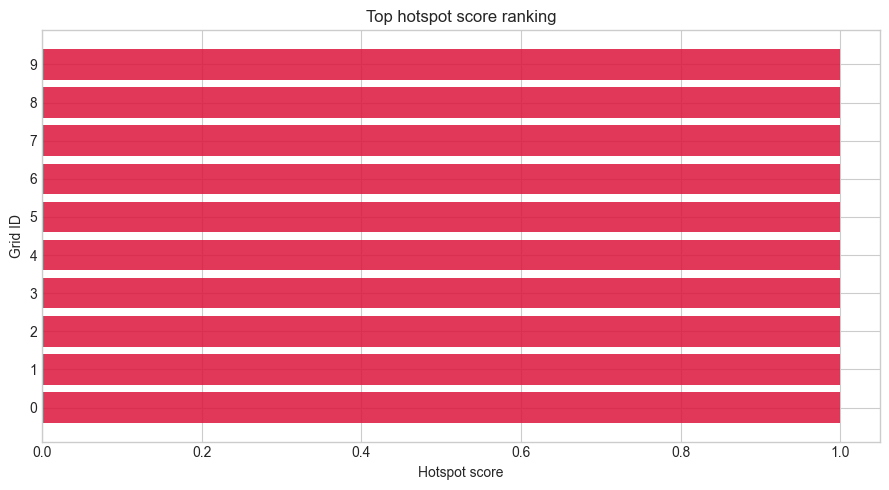

Saved analysis grid to: D:\DEAKIN\SIT374\project\MOP-Code\Playground\ThienKhangNGUYEN\thermal_canopy_hotspots.geojson


In [7]:
if thermal_ready and not grid.empty:
    if 'hotspot_table' in globals() and hotspot_table is not None and not hotspot_table.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_df = hotspot_table.copy().sort_values("hotspot_score")
        ax.barh(plot_df["grid_id"].astype(str), plot_df["hotspot_score"], color="crimson", alpha=0.85)
        ax.set_title("Top hotspot score ranking")
        ax.set_xlabel("Hotspot score")
        ax.set_ylabel("Grid ID")
        plt.tight_layout()
        plt.show()

    output_path = NOTEBOOK_DIR / "thermal_canopy_hotspots.geojson"
    grid.to_crs(epsg=4326).to_file(output_path, driver="GeoJSON")
    print(f"Saved analysis grid to: {output_path}")
else:
    print("No export created because the hotspot grid has not been generated yet.")


## Extended Visual Gallery

Additional figures below are for richer storytelling and reviewer-friendly visual evidence.

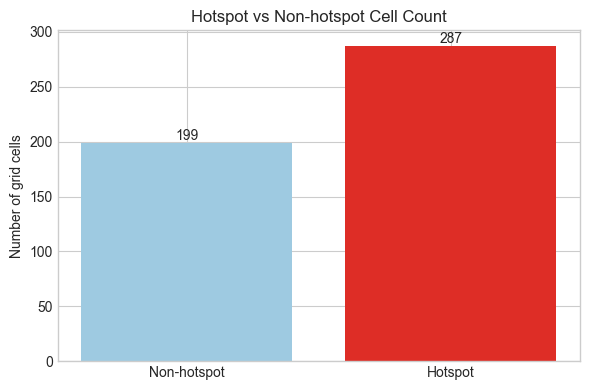

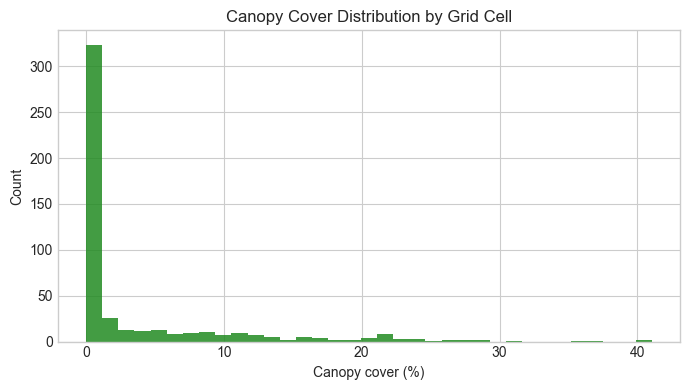

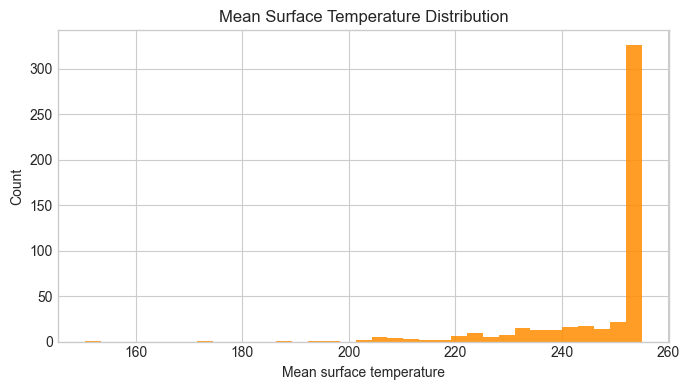

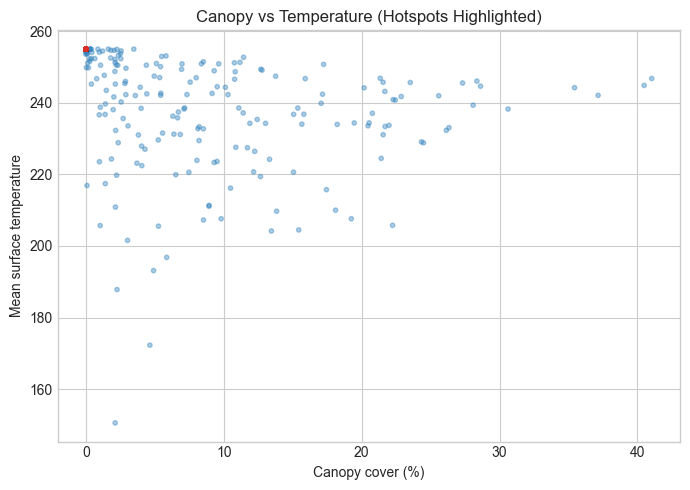

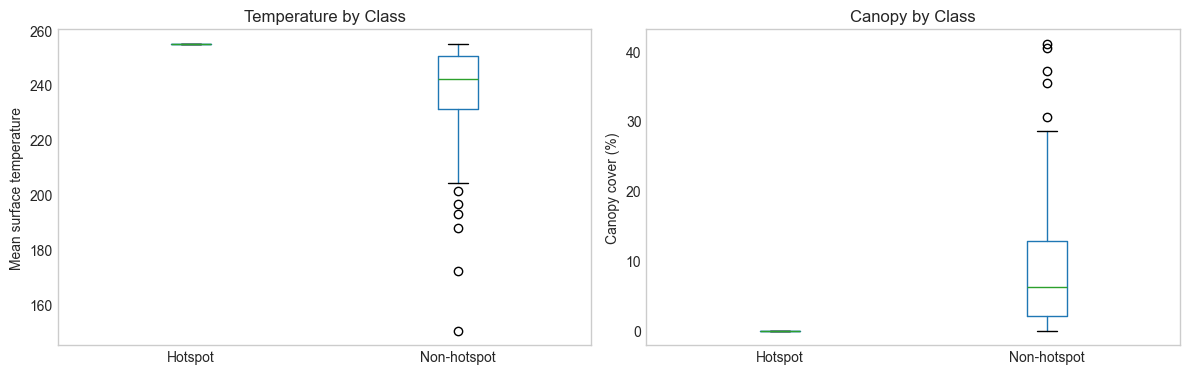

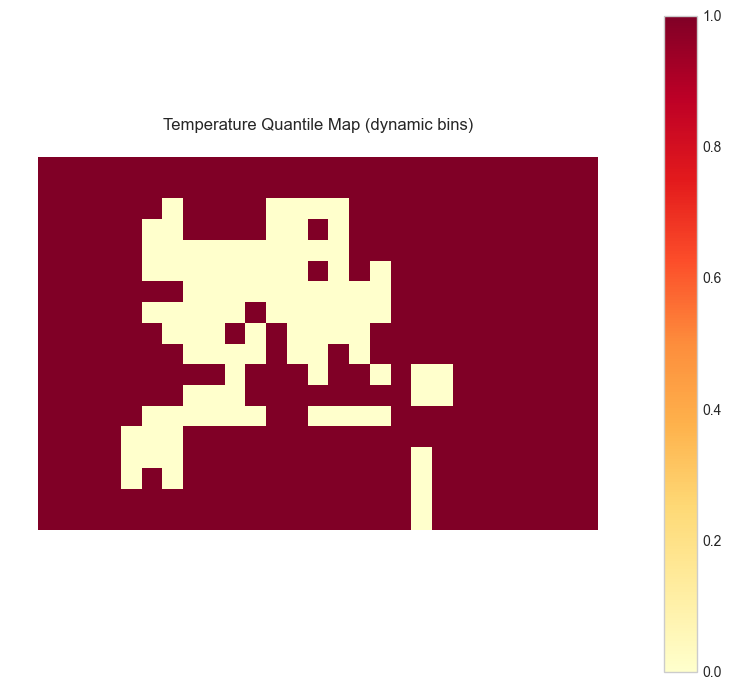

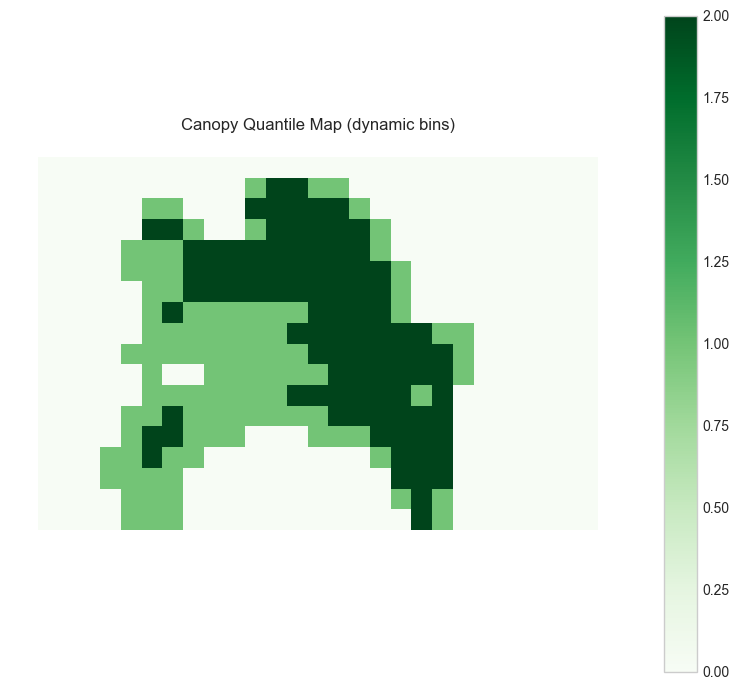

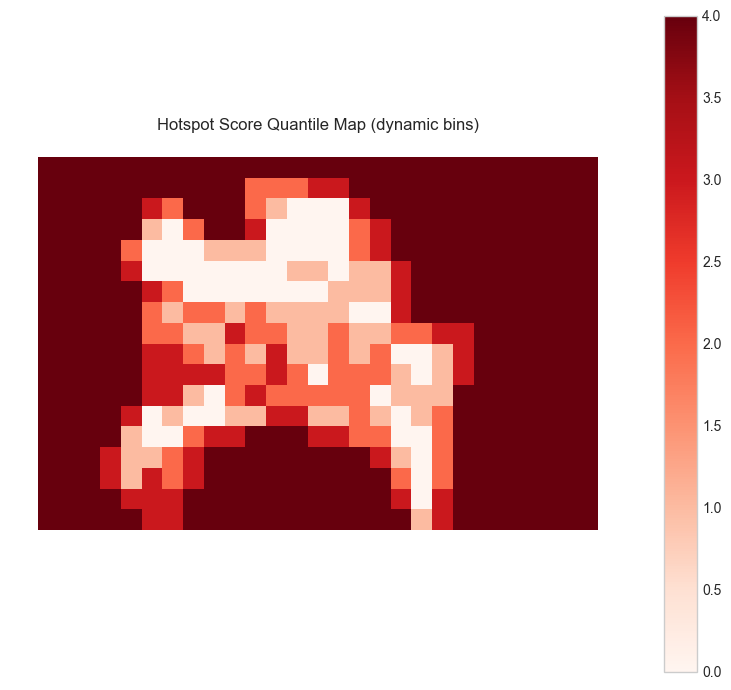

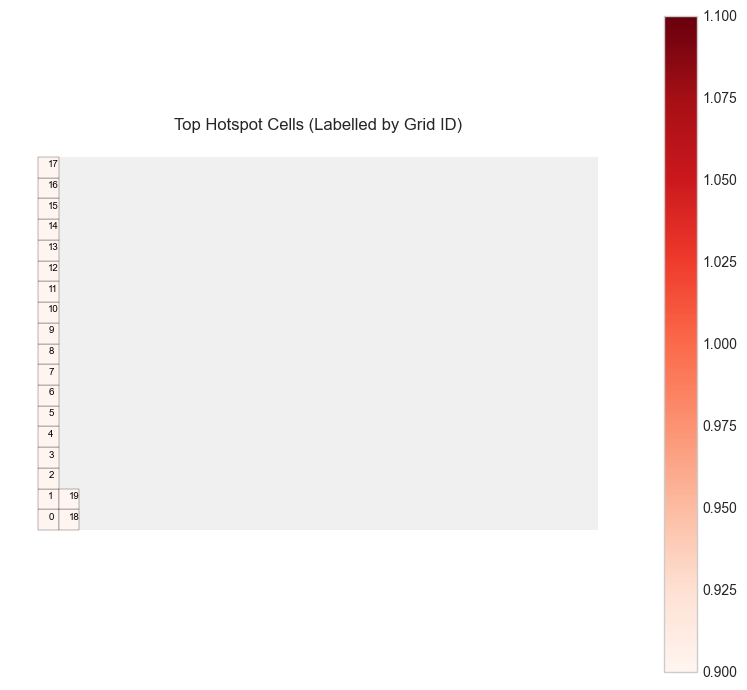

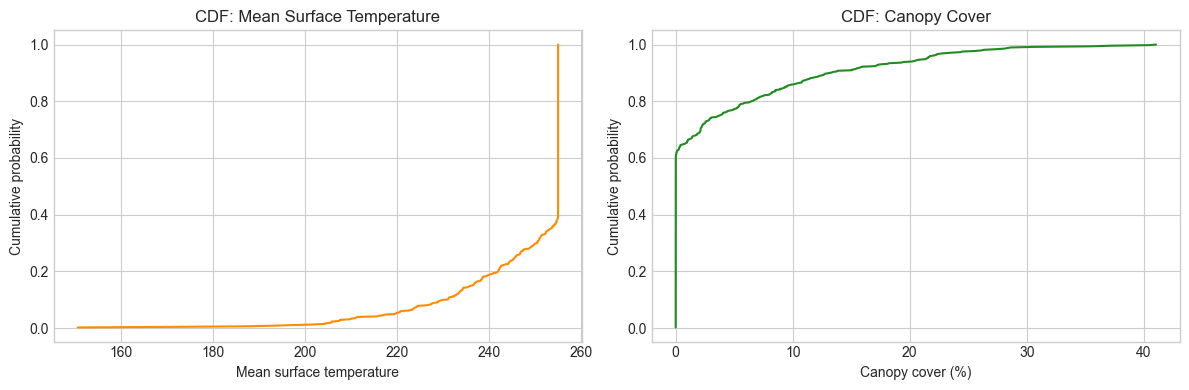

In [8]:
# extra_visual_gallery_v1
if thermal_ready and 'grid' in globals() and grid is not None and not grid.empty and {'mean_surface_temp', 'canopy_cover_pct', 'hotspot_score', 'is_hotspot'}.issubset(grid.columns):
    g = grid.copy()
    g['hotspot_flag'] = np.where(g['is_hotspot'], 'Hotspot', 'Non-hotspot')

    # Figure 1: hotspot count
    counts = g['hotspot_flag'].value_counts().reindex(['Non-hotspot', 'Hotspot']).fillna(0)
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(counts.index, counts.values, color=['#9ecae1', '#de2d26'])
    ax.set_title('Hotspot vs Non-hotspot Cell Count')
    ax.set_ylabel('Number of grid cells')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(b.get_height())}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # Figure 2: canopy cover distribution
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(g['canopy_cover_pct'], bins=35, color='forestgreen', alpha=0.85)
    ax.set_title('Canopy Cover Distribution by Grid Cell')
    ax.set_xlabel('Canopy cover (%)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Figure 3: temperature distribution
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(g['mean_surface_temp'], bins=35, color='darkorange', alpha=0.85)
    ax.set_title('Mean Surface Temperature Distribution')
    ax.set_xlabel('Mean surface temperature')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Figure 4: scatter canopy vs temperature
    sample_scatter = g.sample(min(12000, len(g)), random_state=42)
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = np.where(sample_scatter['is_hotspot'], '#de2d26', '#3182bd')
    ax.scatter(sample_scatter['canopy_cover_pct'], sample_scatter['mean_surface_temp'], s=10, c=colors, alpha=0.4)
    ax.set_title('Canopy vs Temperature (Hotspots Highlighted)')
    ax.set_xlabel('Canopy cover (%)')
    ax.set_ylabel('Mean surface temperature')
    plt.tight_layout()
    plt.show()

    # Figure 5: boxplots by class
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    g.boxplot(column='mean_surface_temp', by='hotspot_flag', ax=axes[0], grid=False)
    axes[0].set_title('Temperature by Class')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Mean surface temperature')
    g.boxplot(column='canopy_cover_pct', by='hotspot_flag', ax=axes[1], grid=False)
    axes[1].set_title('Canopy by Class')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Canopy cover (%)')
    fig.suptitle('')
    plt.tight_layout()
    plt.show()

    # Figure 6: temperature quantile map
    temp_q_idx = pd.qcut(g['mean_surface_temp'], q=5, labels=False, duplicates='drop')
    g['temp_q5'] = temp_q_idx.astype('Int64')
    fig, ax = plt.subplots(figsize=(8, 7))
    g.plot(column='temp_q5', ax=ax, cmap='YlOrRd', legend=True, linewidth=0)
    ax.set_title('Temperature Quantile Map (dynamic bins)')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Figure 7: canopy quantile map
    canopy_q_idx = pd.qcut(g['canopy_cover_pct'], q=5, labels=False, duplicates='drop')
    g['canopy_q5'] = canopy_q_idx.astype('Int64')
    fig, ax = plt.subplots(figsize=(8, 7))
    g.plot(column='canopy_q5', ax=ax, cmap='Greens', legend=True, linewidth=0)
    ax.set_title('Canopy Quantile Map (dynamic bins)')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Figure 8: hotspot score decile map
    score_idx = pd.qcut(g['hotspot_score'], q=10, labels=False, duplicates='drop')
    g['score_decile'] = score_idx.astype('Int64')
    fig, ax = plt.subplots(figsize=(8, 7))
    g.plot(column='score_decile', ax=ax, cmap='Reds', legend=True, linewidth=0)
    ax.set_title('Hotspot Score Quantile Map (dynamic bins)')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Figure 9: top hotspot cells with labels
    top_n = g[g['is_hotspot']].nlargest(min(20, g['is_hotspot'].sum()), 'hotspot_score').copy()
    fig, ax = plt.subplots(figsize=(8, 7))
    g.plot(ax=ax, color='#f0f0f0', linewidth=0)
    if not top_n.empty:
        top_n.plot(ax=ax, column='hotspot_score', cmap='Reds', legend=True, edgecolor='black', linewidth=0.2)
        cent = top_n.geometry.centroid
        for x, y, gid in zip(cent.x, cent.y, top_n['grid_id']):
            ax.text(x, y, str(int(gid)), fontsize=7, color='black')
    ax.set_title('Top Hotspot Cells (Labelled by Grid ID)')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Figure 10: CDF curves for temperature and canopy
    temp_sorted = np.sort(g['mean_surface_temp'].to_numpy())
    canopy_sorted = np.sort(g['canopy_cover_pct'].to_numpy())
    temp_cdf = np.arange(1, len(temp_sorted) + 1) / len(temp_sorted)
    canopy_cdf = np.arange(1, len(canopy_sorted) + 1) / len(canopy_sorted)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(temp_sorted, temp_cdf, color='darkorange')
    axes[0].set_title('CDF: Mean Surface Temperature')
    axes[0].set_xlabel('Mean surface temperature')
    axes[0].set_ylabel('Cumulative probability')

    axes[1].plot(canopy_sorted, canopy_cdf, color='forestgreen')
    axes[1].set_title('CDF: Canopy Cover')
    axes[1].set_xlabel('Canopy cover (%)')
    axes[1].set_ylabel('Cumulative probability')
    plt.tight_layout()
    plt.show()

else:
    print('Extended gallery skipped: thermal/grid outputs are not ready.')


## Interpretation guide

- Cells with **higher thermal values** and **lower canopy cover** are candidate urban heat vulnerability zones.
- The `hotspot_score` is a simple composite ranking, not a physical heat index.
- Because the thermal image is from **2012** and the canopy data is from **2021**, the output should be presented as a broad spatial comparison rather than a direct same-time explanation.

Possible extensions:

- compare hotspots with land use or pedestrian activity
- test different grid sizes
- calculate canopy loss or gain against older tree-canopy datasets
- export hotspot cells for web mapping or planning dashboards
